# Tutorial 7: Build and Visualize Hi-M Contact Matrices

## Objective

Convert chromatin traces into **pairwise distance matrices** and **contact probability matrices**,
then visualize them as publication-quality heatmaps.

This tutorial covers two scripts:

1. **`trace_to_matrix`** — computes single-cell pairwise distance (PWD) matrices from a trace file
   and produces four plots by default (Hi-M contact matrix, PWD median, PWD KDE, N-matrix). The all-pairs distance histogram plot is optional because it can dominate runtime for large barcode sets.
2. **`plot_him_matrix`** — re-plots a Hi-M matrix from the saved `.npy` data with custom options
   (colormap, color range, mode, triangular display, NaN threshold…).

## Scientific context

Contact matrices summarize pairwise interactions across all traces:
- **Contact probability (Hi-M)**: fraction of traces where two barcodes are closer than a distance threshold (default 0.25 µm).
- **PWD median / KDE**: ensemble pairwise distance estimated via median or kernel density peak.
- **N-matrix**: number of valid (non-NaN) measurements per barcode pair — reveals data coverage.

These matrices reveal chromatin folding patterns such as topologically associating domains (TADs),
long-range loops, and compartments.

## Input

We use the Pdx1-positive trace file produced by Tutorial 6 (mask assignment + split):

| File | Description |
|------|-------------|
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Pdx1.ecsv` | Traces inside the Pdx1 mask (single ROI) |

In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2"
dest_path = f"{data_path}/output"

# Cortex tissue from tutorials 1-5
input_trace = f"{dest_path}/merged_traces_filtered_all.ecsv"

# Base name for all matrix outputs
matrix_base = f"{dest_path}/merged_traces_filtered_all_Matrix"

print(f"Input trace: {input_trace}")

Input trace: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/output/merged_traces_filtered_all.ecsv


## Step 1: Build matrices with `trace_to_matrix`

`trace_to_matrix` reads a trace file and computes:
- A **3D single-cell PWD matrix** (shape: n_barcodes × n_barcodes × n_traces) saved as `.npy`
- An **N-matrix** (count of valid measurements per barcode pair) saved as `.npy`
- A **unique barcodes list** saved as `.ecsv`
- **Four default plots**: Hi-M contact matrix, PWD median, PWD KDE, and N-matrix
- An **optional distance histogram plot** (`*_Matrix_PWDhistograms.png`) when `--plot_histograms` is passed

### Parameters

| Option | Default | Description |
|--------|---------|-------------|
| `--input` | — | Input trace file (ECSV) |
| `--distance_threshold` | `inf` | Maximum distance allowed (discard pairs beyond this) |
| `-F` | `./` | Output folder (for data files) |
| `--n_jobs` | `1` | Parallel workers for per-trace PWD matrix construction (`-1` uses all CPUs) |
| `--plot_histograms` | disabled | Also calculate and save all-pairs PWD KDE histograms. This is skipped by default because it is often the slowest step. |

In [11]:
!trace_to_matrix --input {input_trace}

# Optional: add --plot_histograms if you also need the all-pairs PWD KDE histogram figure.
# This can be slow for large barcode sets.
# !trace_to_matrix --input {input_trace} --plot_histograms

------- Running trace_to_matrix.py --------
Convert a trace file to a matrix using pyHiM core routines.


$ trace file to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/output/merged_traces_filtered_all.ecsv']
> Starting load trace table...
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/output/merged_traces_filtered_all.ecsv
$ Elapsed time for load trace table: 0.62 s
> Starting build single-cell PWD matrix...
$ Found 64 barcodes and 1780 traces. INFO
> Processing traces... INFO
Building per-trace PWD matrices: 100%|███| 1780/1780 [00:00<00:00, 3572.65it/s]
$ Elapsed time for build single-cell PWD matrix: 1.06 s
> Starting calculate N-matrix...
$ Elapsed time for calculate N-matrix: 0.01 s
> Starting plot all matrices and histograms...
> Starting plot PWD matrix - KDE...
Calculating ensemble PWD matrix (KDE): 100%|███| 64/64 [02:33<00:00,  2.41s/it]
$ Elapsed time f

### Output files

All outputs use the pattern `<input_basename>_Matrix_<suffix>`:

| File | Format | Description |
|------|--------|-------------|
| `*_Matrix_PWDscMatrix.npy` | NumPy binary | 3D single-cell pairwise distance matrix |
| `*_Matrix_Nmatrix.npy` | NumPy binary | 2D N-matrix (data coverage) |
| `*_Matrix_uniqueBarcodes.ecsv` | Text | List of unique barcode IDs |
| `*_Matrix_HiMmatrix.png` | Image | Contact probability heatmap |
| `*_Matrix_PWDmatrixMedian.png` | Image | PWD matrix (median) |
| `*_Matrix_PWDmatrixKDE.png` | Image | PWD matrix (KDE peak) |
| `*_Matrix_Nmatrix.png` | Image | N-matrix heatmap |
| `*_Matrix_PWDhistograms.png` | Image | Optional distance histograms for all barcode pairs; only produced with `--plot_histograms` |

## Step 2: Hi-M contact probability matrix

The **Hi-M matrix** shows the fraction of traces where each barcode pair is closer than a
distance threshold (default: 0.25 µm). Higher values (warm colors) indicate more frequent contacts.

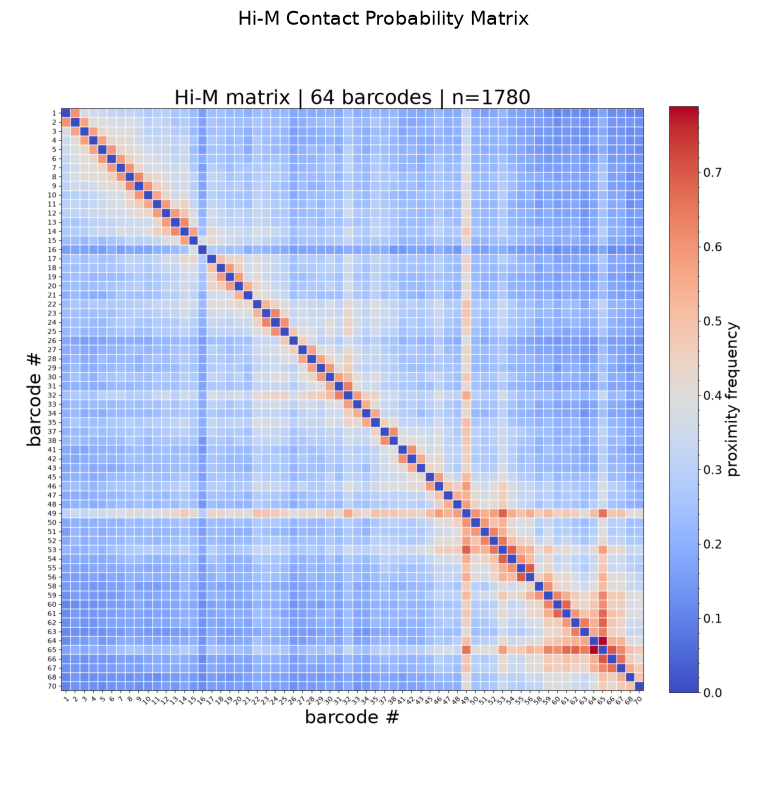

In [12]:
img = mpimg.imread(f"{matrix_base}_HiMmatrix.png")
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title("Hi-M Contact Probability Matrix", fontsize=14)
plt.tight_layout()
plt.show()

**How to read this matrix:**
- Axes show barcode IDs (genomic loci along the chromatin fiber).
- The **diagonal** is always high (a barcode is always close to itself).
- **Off-diagonal warm spots** indicate frequent spatial proximity between distant genomic loci → potential loops or TAD boundaries.
- **Blocks along the diagonal** suggest topologically associating domains (TADs).

## Step 3: Pairwise distance matrices

Two PWD representations are computed:
- **Median**: robust central tendency of 3D distances per barcode pair.
- **KDE**: peak of the kernel density estimate — captures the most probable distance, useful when distributions are skewed.

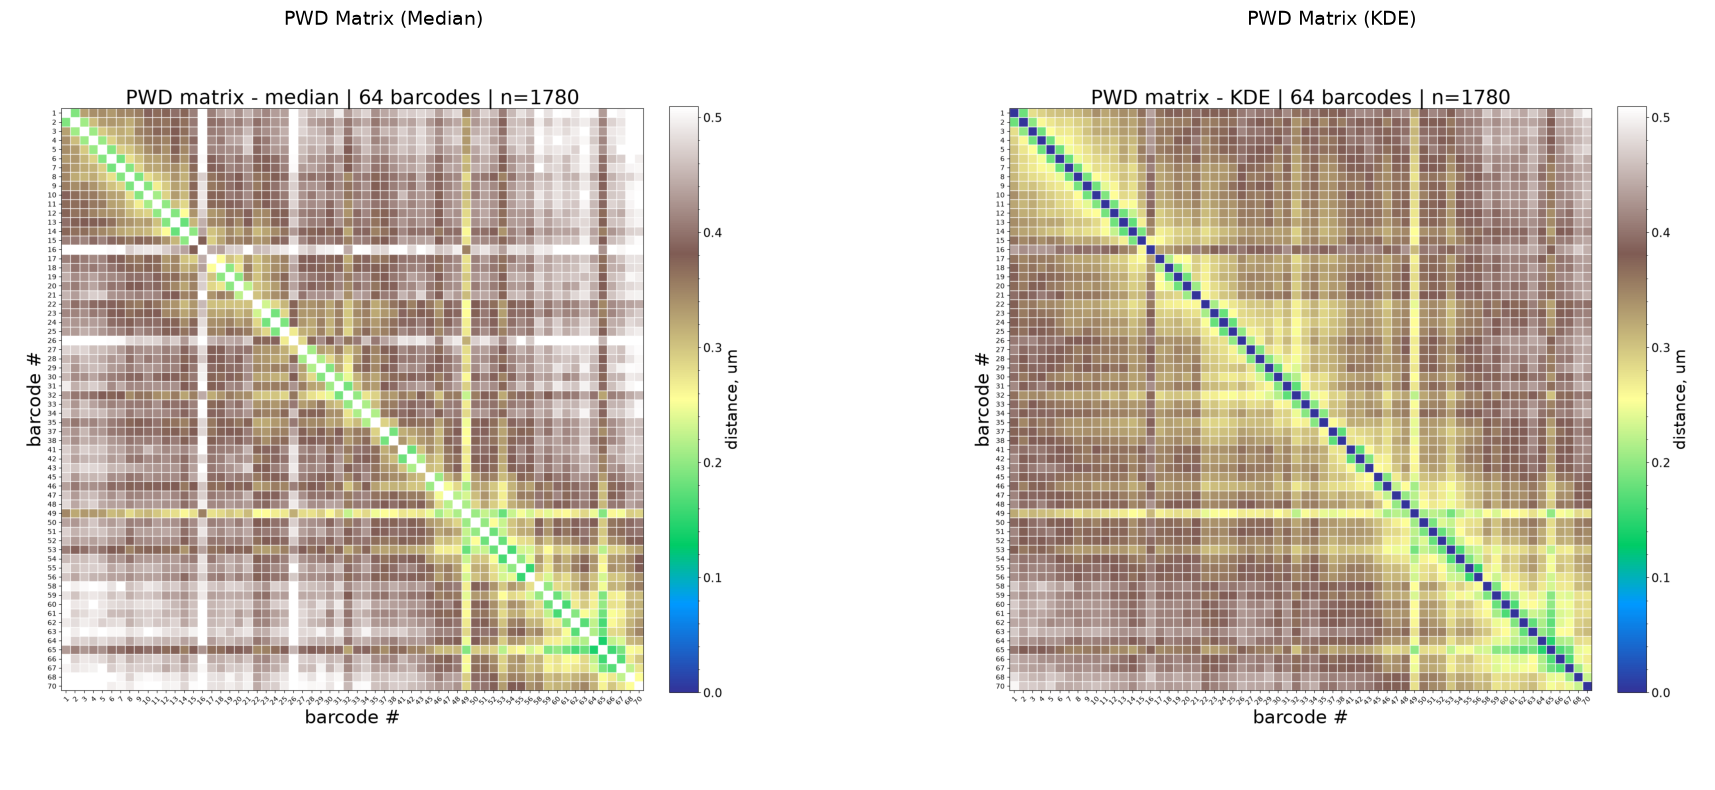

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, suffix, title in zip(
    axes,
    ["_PWDmatrixMedian.png", "_PWDmatrixKDE.png"],
    ["PWD Matrix (Median)", "PWD Matrix (KDE)"]
):
    img = mpimg.imread(f"{matrix_base}{suffix}")
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()


**Interpretation:**
- Low values along the diagonal (warm colors in `terrain` colormap) = nearby genomic loci are physically close (expected).
- Off-diagonal low-distance spots indicate long-range contacts.
- KDE is often less noisy than median for sparse data.

## Step 4: N-matrix and distance histograms

The **N-matrix** shows how many valid (non-NaN) pairwise measurements exist for each barcode pair.
Low N values indicate poor coverage — those entries should be interpreted with caution.

The optional **distance histograms** show the full distribution (KDE) of 3D distances for every barcode pair. Because this figure can be much slower than the matrix outputs, it is not produced by default. Re-run Step 1 with `--plot_histograms` if you need it before executing the display cell below.

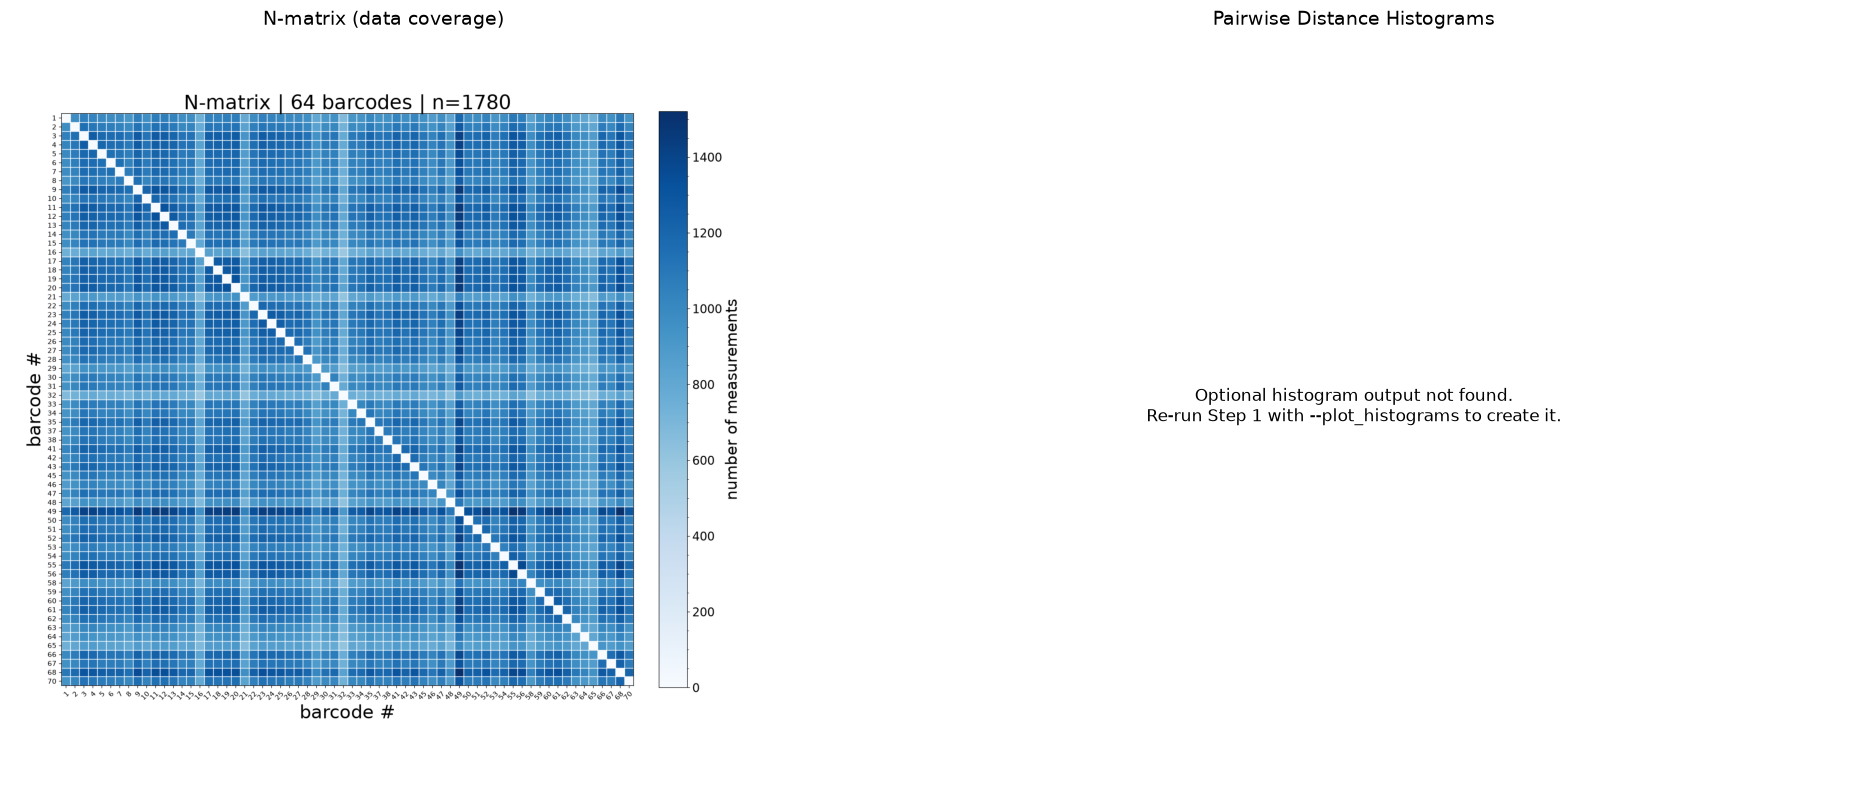

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_specs = [
    ("_Nmatrix.png", "N-matrix (data coverage)", True),
    ("_PWDhistograms.png", "Pairwise Distance Histograms", False),
]

for ax, (suffix, title, produced_by_default) in zip(axes, plot_specs):
    file_name = f"{matrix_base}{suffix}"
    if produced_by_default or os.path.exists(file_name):
        img = mpimg.imread(file_name)
        ax.imshow(img)
    else:
        ax.text(
            0.5,
            0.5,
            "Optional histogram output not found.\nRe-run Step 1 with --plot_histograms to create it.",
            ha="center",
            va="center",
            fontsize=12,
        )
    ax.axis('off')
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()


## Step 5: Re-plot with `plot_him_matrix`

`plot_him_matrix` lets you **re-visualize** a previously computed matrix with custom display options,
without re-running the full computation.

It reads:
- The 3D single-cell PWD matrix (`*_PWDscMatrix.npy`)
- The unique barcodes list (`*_uniqueBarcodes.ecsv`)

### Key parameters

| Option | Default | Description |
|--------|---------|-------------|
| `-M` / `--matrix` | — | Single-cell PWD matrix (`.npy`) |
| `-B` / `--barcodes` | — | Unique barcodes file |
| `--mode` | `proximity` | `proximity` (contact frequency), `median`, or `KDE` |
| `-T` / `--threshold` | `0.25` | Contact distance threshold in µm (for `proximity` mode) |
| `--c_min` / `--c_max` | auto | Colormap range |
| `--c_map` | `coolwarm` | Matplotlib colormap name |
| `--nan_threshold` | `None` | Mask bins where NaN percentage exceeds this value (0–1) |
| `--triangular` | off | Show only upper or lower triangle |
| `--triangular_mode` | `upper` | `upper` or `lower` triangle |
| `-O` / `--output` | `plots` | Output folder for the plot |
| `--plot_format` | `png` | `png`, `pdf`, or `svg` |

### Example: proximity matrix with custom threshold

Recompute the contact probability using a different distance threshold (e.g. 0.30 µm instead of the default 0.25 µm):

In [15]:
sc_matrix = f"{matrix_base}_PWDscMatrix.npy"
barcodes = f"{matrix_base}_uniqueBarcodes.ecsv"

!plot_him_matrix -M {sc_matrix} -B {barcodes} --mode proximity -T 0.15 -O {data_path}/plots

------- Running plot_him_matrix.py --------
Calculate and plot PWD and proximity matrices.

Output path: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots
$ Matrix loaded: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/output/merged_traces_filtered_all_Matrix_PWDscMatrix.npy
$ Unique barcodes loaded: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70]
$ averaging method: proximity
$ calculating contact probability matrix
Output data: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots/Fig_merged_traces_filtered_all_Matrix_PWDscMatrix_proximity_norm_T0.15_0.02-0.53.npy


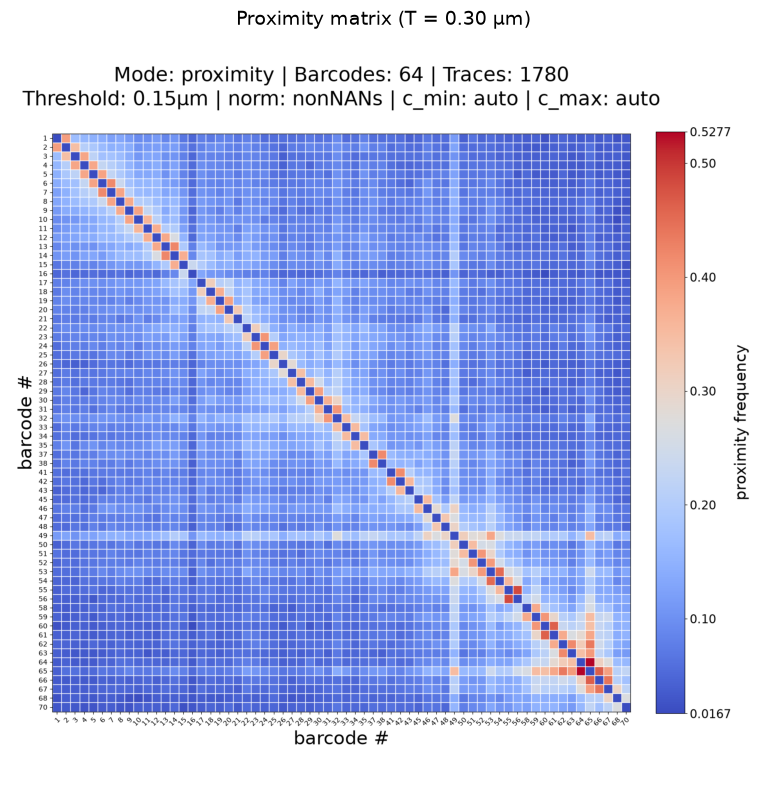

Plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots/Fig_merged_traces_filtered_all_Matrix_PWDscMatrix_proximity_norm_T0.15_0.02-0.53.png


In [16]:
import glob
plots_path = f"{data_path}/plots"

matches = sorted(glob.glob(f"{plots_path}/Fig_*_proximity_norm_T0.15_*.png"))
if matches:
    img = mpimg.imread(matches[0])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Proximity matrix (T = 0.30 µm)", fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"Plot: {matches[0]}")

### Example: median PWD matrix

In [17]:
!plot_him_matrix -M {sc_matrix} -B {barcodes} --mode median -O {data_path}/plots

------- Running plot_him_matrix.py --------
Calculate and plot PWD and proximity matrices.

Output path: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots
$ Matrix loaded: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/output/merged_traces_filtered_all_Matrix_PWDscMatrix.npy
$ Unique barcodes loaded: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70]
$ averaging method: median
/home/zidoum/miniforge3/envs/traceratops/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
Output data: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots/Fig_merged_traces_filtered_all_Matrix_PWDscMatrix_median_norm_0.14-0.58.npy


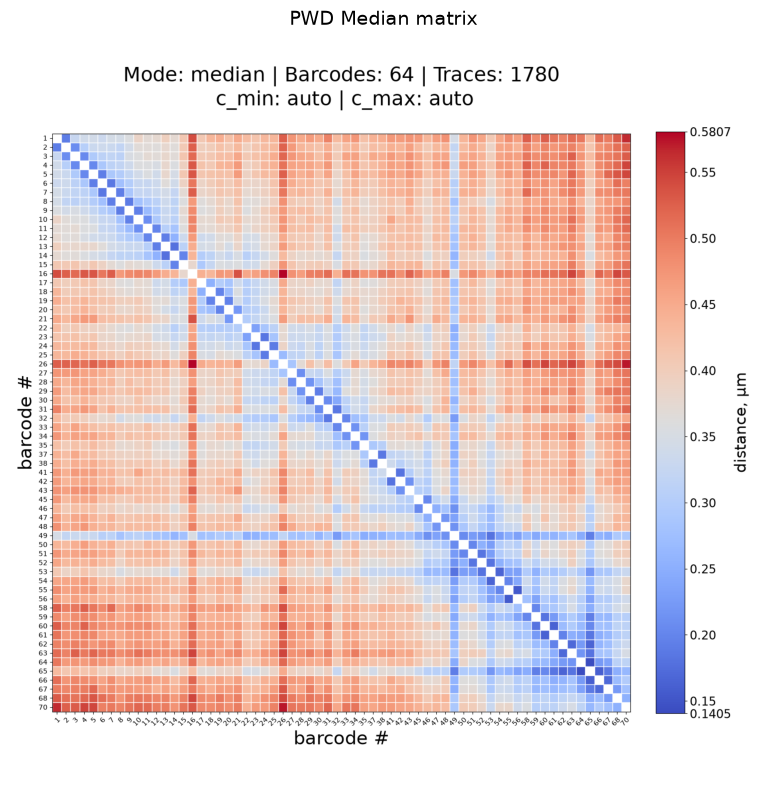

Plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettinger/Replicate2/plots/Fig_merged_traces_filtered_all_Matrix_PWDscMatrix_median_norm_0.14-0.58.png


In [18]:
matches = sorted(glob.glob(f"{plots_path}/Fig_*_median_norm_*.png"))
if matches:
    img = mpimg.imread(matches[0])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("PWD Median matrix", fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"Plot: {matches[0]}")

## Summary

### Workflow

```
trace file (.ecsv)
       │
       ▼
trace_to_matrix              →  4 default plots + 3 data files
                              →  optional PWD histograms with --plot_histograms
       │
       ▼
plot_him_matrix (optional)   →  re-plot with custom options
```

### Produced by `trace_to_matrix`

| Plot | What it shows |
|------|---------------|
| `*_HiMmatrix.png` | Contact probability (proximity frequency) |
| `*_PWDmatrixMedian.png` | Pairwise distance — median |
| `*_PWDmatrixKDE.png` | Pairwise distance — KDE peak |
| `*_Nmatrix.png` | Data coverage (N measurements per pair) |
| `*_PWDhistograms.png` | Optional full distance distributions (all pairs; produced with `--plot_histograms`) |

### Customization with `plot_him_matrix`

| Use case | Command |
|----------|----------|
| Change distance threshold | `--mode proximity -T 0.30` |
| Median distance matrix | `--mode median` |
| KDE distance matrix | `--mode KDE` |
| Custom colormap | `--c_map viridis --c_min 0.0 --c_max 0.5` |
| Mask sparse bins | `--nan_threshold 0.8` |
| Triangular plot | `--triangular --triangular_mode upper` |
| PDF for publication | `--plot_format pdf` |

**Next:** [Tutorial 8 — Multiway Colocalization](tutorial_08_multiway_coloc.ipynb)